🚀 Training starting...
Epoch 0: Loss = 0.471338
Epoch 500: Loss = 0.000166
Epoch 1000: Loss = 0.004526
Epoch 1500: Loss = 0.000018


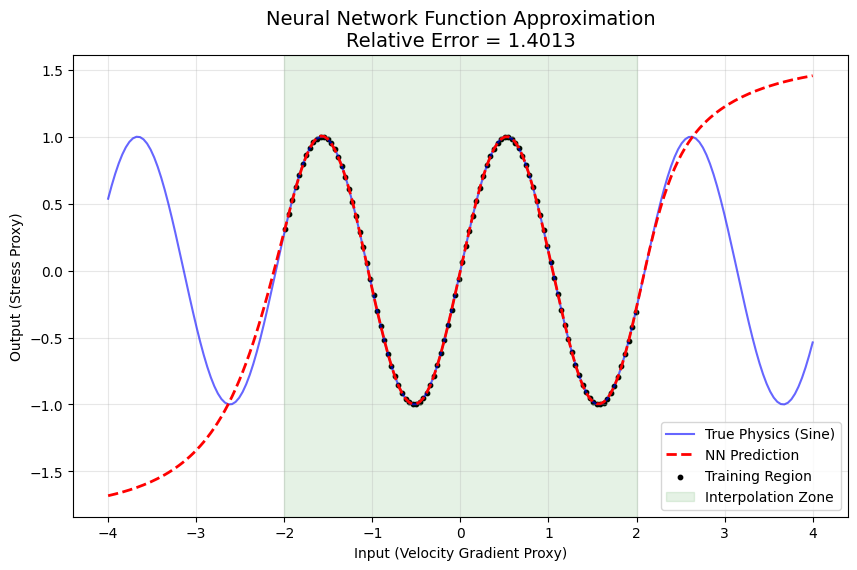

In [1]:
"""
Phase 1: Mathematical Foundations of Neural Networks
Project: Learning Constitutive Laws in 2D Granular Flow
Author: Abhishek Tagalpallewar

Description:
This script demonstrates the fundamental ability of a Feedforward Neural Network 
to approximate non-linear periodic functions (Sine waves). 
This serves as the 'sanity check' before moving to complex granular stress data.
"""

import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import numpy as np

# ---------------------------------------------------
# 1. DATA GENERATION (The Sine "Experimental" Data)
# ---------------------------------------------------
# We generate a full range, but only 'train' on a subset to test interpolation.
x_full = torch.linspace(-4, 4, 200).unsqueeze(1)
y_full = torch.sin(3 * x_full)

# Create a training mask (simulating limited experimental window)
mask = (x_full >= -2) & (x_full <= 2)
x_train = x_full[mask.squeeze()]
y_train = y_full[mask.squeeze()]

# ---------------------------------------------------
# 2. MODEL DEFINITION (3-Layer Architecture)
# ---------------------------------------------------
# We use a 3-layer network as determined by our 'Architectural Tournament'.
# Tanh activation is used here because it is smooth and symmetric, 
# making it ideal for periodic (Sine) and oscillatory (Stress) data.
class SineApproximator(nn.Module):
    def __init__(self):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(1, 20),   # Input Layer
            nn.Tanh(),          # Activation 1
            nn.Linear(20, 20),  # Hidden Layer 2
            nn.Tanh(),          # Activation 2
            nn.Linear(20, 1)    # Output Layer (Predicted Stress)
        )

    def forward(self, x):
        return self.network(x)

# ---------------------------------------------------
# 3. TRAINING LOGIC (Backpropagation & Optimization)
# ---------------------------------------------------
def train_and_validate():
    model = SineApproximator()
    loss_fn = nn.MSELoss()
    
    # AdamW is used for better weight decay, preventing overfitting to noise.
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

    print("🚀 Training starting...")
    for epoch in range(2000):
        optimizer.zero_grad()           # Clear gradients from previous step
        y_pred = model(x_train)         # Feedforward
        loss = loss_fn(y_pred, y_train) # Calculate Error
        loss.backward()                 # Backpropagation (Calculate Gradients)
        optimizer.step()                # Update Weights & Biases

        if epoch % 500 == 0:
            print(f"Epoch {epoch}: Loss = {loss.item():.6f}")

    # 4. PREDICTION & ERROR ANALYSIS
    with torch.no_grad():
        y_full_pred = model(x_full)

    # Relative Error (RE) calculation - The metric used throughout the project
    rel_error = torch.mean(torch.abs((y_full_pred - y_full) / (y_full + 1e-8))).item()
    
    return y_full_pred, rel_error

# ---------------------------------------------------
# 5. VISUALIZATION
# ---------------------------------------------------
y_pred, error_val = train_and_validate()

plt.figure(figsize=(10, 6))
plt.plot(x_full.numpy(), y_full.numpy(), 'b-', alpha=0.6, label="True Physics (Sine)")
plt.plot(x_full.numpy(), y_pred.numpy(), 'r--', linewidth=2, label="NN Prediction")
plt.scatter(x_train.numpy(), y_train.numpy(), color='black', s=10, label="Training Region")

# Highlight training region to show Interpolation vs Extrapolation
plt.axvspan(-2, 2, color='green', alpha=0.1, label="Interpolation Zone")

plt.title(f"Neural Network Function Approximation\nRelative Error = {error_val:.4f}", fontsize=14)
plt.xlabel("Input (Velocity Gradient Proxy)")
plt.ylabel("Output (Stress Proxy)")
plt.legend()
plt.grid(alpha=0.3)
plt.show()